![Alt text](images/image_3.jpg)


# Mini_Projet_Pandas

**Professeur :** Dr. Evens TOUSSAINT  

**Étudiants :**  
- Jameson PIERREVILLE  
- Fabrice HERARD  
- Steve CALIXTE

## Presentation
![Alt text](images/download_3.WEBP)

Nous occupons le rôle de Data Analyst au sein de l’entreprise EduMart, une boutique spécialisée dans la vente de cours, livres, logiciels, crédits cloud, ordinateurs portables et accessoires. Notre tâche consistent à nettoyer et analyser les données de ventes ainsi que le comportement des clients (retours, avis, etc.) à l’aide de Pandas.


## The Data
![Alt text](images/download_4.WEBP)

Notre jeu de données est composé de trois fichiers CSV décrivant les clients, les produits et les transactions de l’entreprise EduMart. Les données vont de la période allant de 2024 à 2025. Le dataset qui enregistre les transactions comptent environ 2200 lignes. 





## Methode
Pour réaliser ce travail, nous utiliserons les outils offerts par _Python_, principalement la bibliothèque _pandas_, qui nous permettra de manipuler les _DataFrames_. Dans un premier temps, nous mènerons une _analyse exploratoire des données_ afin d’identifier, entre autres, la présence de valeurs manquantes.

Dans un deuxième temps, nous traiterons ces différentes anomalies à l’aide de techniques de _nettoyage et de préparation des données_. Enfin, nous exploiterons les données en utilisant des _méthodes statistiques_ et des _visualisations graphiques_ afin d’en extraire des informations pertinentes.

Comme outil collaboratif, nous utiliserons _GitHub_, qui nous permettra d’héberger notre projet, mais aussi de collaborer efficacement et en temps réel sur la production et la révision du code.


### Importation des bibliotheques

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importation et exploration des donnees

In [118]:
# Chargement du fichier clients et affichage des 10 premières lignes
customers=pd.read_csv("data/raw/customers.csv")
customers.head(10)

,customer_id,age,gender,city,segment,signup_date
0,C0001,28,M,Gonaïves,Entreprise,2025-09-26
1,C0002,16,M,Gonaïves,Professionnel,2024-01-19
2,C0003,unknown,M,Saint-Marc,Indépendant,2024-05-05
3,C0004,46,F,Port-au-Prince,Professionnel,2024-11-16
4,C0005,19,M,Cap-Haïtien,Professionnel,2024-11-21
5,C0006,20,M,Port-au-Prince,Entreprise,2023-11-04
6,C0007,44,F,Port-au-Prince,Professionnel,2025-09-29
7,C0008,52,M,Paris,Étudiant,2024-03-28
8,C0009,20,M,Saint-Marc,Professionnel,2025-06-17
9,C0010,26,F,NaN,Étudiant,2025-09-22


In [119]:
# Chargement du fichier produits et affichage des 10 premières lignes
products=pd.read_csv("data/raw/products.csv")
products.head(10)

,product_id,category,brand,product_name,unit_price
0,P001,Laptop,HP,Ultrabook 14,1681.08
1,P002,Laptop,ASUS,Notebook 15,1058.14
2,P003,Livre,Manning,Data Engineering,40.16
3,P004,Accessoire,Anker,SSD externe,91.27
4,P005,Laptop,HP,Gaming 16,1123.49
5,P006,Accessoire,Anker,Dock USB-C,75.23
6,P007,Logiciel,Microsoft,Licence IDE,308.43
7,P008,Logiciel,JetBrains,Suite bureautique,68.48
8,P009,Cours,OpenSkills,NLP,157.91
9,P010,Livre,Manning,Python pour la Data,28.28


In [120]:
# Chargement du fichier oder_lines et affichage des 10 premières lignes
order_lines=pd.read_csv("data/raw/order_lines.csv")
order_lines.head(10)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,channel,marketing_source,delivery_days,returned,review_score,segment,city,category
0,O00001,C0201,P031,2024-06-16,4,165.54,0.18,662.16,542.97,Carte,App,Organique,1.0,0,5.0,Indépendant,Port-au-Prince,Cours
1,O00002,C0141,P041,2024-06-10,5,46.48,0.14,232.40,199.86,Carte,Web,Réseaux sociaux,0.0,0,4.0,Étudiant,Abidjan,Livre
2,O00003,C0025,P005,2024-08-29,2,1123.49,0.04,2246.98,2157.10,Virement,Web,Réseaux sociaux,3.0,0,4.0,Étudiant,Cap-Haïtien,Laptop
3,O00004,C0188,P042,2024-01-27,2,68.31,0.22,136.62,106.56,Carte,Boutique,Partenariat,0.0,0,4.0,Indépendant,Abidjan,Cloud
4,O00005,C0023,P052,2025-08-06,3,1932.53,0.17,5797.59,4812.00,Carte,Web,Référencement payant,9.0,0,5.0,Professionnel,Cap-Haïtien,Laptop
5,O00006,C0374,P046,2025-09-03,3,125.59,0.24,376.77,286.35,Mobile Money,Web,Partenariat,1.0,1,4.0,Étudiant,Port-au-Prince,Cours
6,O00007,C0045,P018,2024-10-01,2,52.97,0.12,105.94,93.23,Cash,Boutique,Réseaux sociaux,2.0,0,NaN,Professionnel,Mirebalais,Cours
7,O00008,C0347,P022,2025-08-21,2,50.57,0.10,101.14,91.03,Carte,Web,Organique,3.0,0,4.0,Étudiant,Saint-Marc,Livre
8,O00009,C0290,P058,2025-07-06,1,222.36,0.17,222.36,184.56,Mobile Money,Web,Réseaux sociaux,3.0,0,4.0,Indépendant,Kinshasa,Cloud
9,O00010,C0494,P048,2025-07-27,2,74.61,0.02,149.22,146.24,Virement,Web,Direct,3.0,0,4.0,Professionnel,Port-au-Prince,Cours


In [121]:
customers.shape


(500, 6)

In [122]:
products.shape


(60, 5)

In [123]:
order_lines.shape

(2225, 18)

Validating data types

In [124]:
# Résumé des colonnes, types et valeurs non nulles des clients
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  500 non-null    object
 1   age          500 non-null    object
 2   gender       490 non-null    object
 3   city         485 non-null    object
 4   segment      500 non-null    object
 5   signup_date  500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


On remarque que l'age en soit est de type object au lieu d'une type numerique on fait la conversion

In [125]:
# Résumé des colonnes, types et valeurs non nulles de la table Product
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    60 non-null     object 
 1   category      60 non-null     object 
 2   brand         60 non-null     object 
 3   product_name  60 non-null     object 
 4   unit_price    60 non-null     float64
dtypes: float64(1), object(4)
memory usage: 2.5+ KB


In [126]:
# Résumé des colonnes, types et valeurs non nulles de la table Order_Line
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2225 non-null   object 
 1   customer_id       2225 non-null   object 
 2   product_id        2225 non-null   object 
 3   order_date        2225 non-null   object 
 4   quantity          2225 non-null   int64  
 5   unit_price        2225 non-null   float64
 6   discount_pct      2225 non-null   float64
 7   gross_amount      2225 non-null   float64
 8   net_amount        2225 non-null   float64
 9   payment_method    2225 non-null   object 
 10  channel           2225 non-null   object 
 11  marketing_source  2225 non-null   object 
 12  delivery_days     2181 non-null   float64
 13  returned          2225 non-null   int64  
 14  review_score      2115 non-null   float64
 15  segment           2225 non-null   object 
 16  city              2155 non-null   object 


In [127]:
# Résumé statistique pour toutes les colonnes de la table Customers
customers.describe(include="all")

,customer_id,age,gender,city,segment,signup_date
count,500,500,490,485,500,500
unique,500,36,3,16,4,386
top,C0001,16,F,Port-au-Prince,Étudiant,2024-07-25
freq,1,40,235,135,182,3


In [128]:
# Résumé statistique pour toutes les colonnes de la table Product
products.describe(include="all")

,product_id,category,brand,product_name,unit_price
count,60,60,60,60,60.000000
unique,60,6,23,28,NaN
top,P001,Cours,HP,NLP,NaN
freq,1,18,6,5,NaN
mean,NaN,NaN,NaN,NaN,354.351000
std,NaN,NaN,NaN,NaN,514.712694
min,NaN,NaN,NaN,NaN,24.970000
25%,NaN,NaN,NaN,NaN,72.845000
50%,NaN,NaN,NaN,NaN,124.245000
75%,NaN,NaN,NaN,NaN,308.502500


In [129]:
# Résumé statistique pour toutes les colonnes de la table Oder_line
order_lines.describe(include="all") 

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,channel,marketing_source,delivery_days,returned,review_score,segment,city,category
count,2225,2225,2225,2225,2225.000000,2225.000000,2225.000000,2225.000000,2225.000000,2225,2225,2225,2181.000000,2225.000000,2115.000000,2225,2155,2225
unique,2200,492,60,683,NaN,NaN,NaN,NaN,NaN,4,3,6,NaN,NaN,NaN,4,16,6
top,O00410,C0363,P060,2025-02-06,NaN,NaN,NaN,NaN,NaN,Carte,Web,Organique,NaN,NaN,NaN,Étudiant,Port-au-Prince,Cours
freq,2,12,52,10,NaN,NaN,NaN,NaN,NaN,895,1218,646,NaN,NaN,NaN,805,600,705
mean,NaN,NaN,NaN,NaN,2.966292,354.163991,0.115097,1049.257438,926.902701,NaN,NaN,NaN,4.112334,0.042247,4.357447,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.426634,506.596786,0.068481,1711.115156,1510.243744,NaN,NaN,NaN,4.584551,0.201198,0.595541,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-1.000000,24.970000,0.000000,24.970000,20.110000,NaN,NaN,NaN,0.000000,0.000000,2.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.000000,74.300000,0.060000,158.910000,143.730000,NaN,NaN,NaN,1.000000,0.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,3.000000,125.590000,0.110000,362.580000,314.530000,NaN,NaN,NaN,3.000000,0.000000,4.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.000000,308.720000,0.160000,898.300000,796.500000,NaN,NaN,NaN,6.000000,0.000000,5.000000,NaN,NaN,NaN


### Nettoyage des Donnees

In [130]:
customers.head(20)

,customer_id,age,gender,city,segment,signup_date
0,C0001,28,M,Gonaïves,Entreprise,2025-09-26
1,C0002,16,M,Gonaïves,Professionnel,2024-01-19
2,C0003,unknown,M,Saint-Marc,Indépendant,2024-05-05
3,C0004,46,F,Port-au-Prince,Professionnel,2024-11-16
4,C0005,19,M,Cap-Haïtien,Professionnel,2024-11-21
5,C0006,20,M,Port-au-Prince,Entreprise,2023-11-04
6,C0007,44,F,Port-au-Prince,Professionnel,2025-09-29
7,C0008,52,M,Paris,Étudiant,2024-03-28
8,C0009,20,M,Saint-Marc,Professionnel,2025-06-17
9,C0010,26,F,NaN,Étudiant,2025-09-22


In [131]:
#
customers.isna().sum()

customer_id     0
age             0
gender         10
city           15
segment         0
signup_date     0
dtype: int64

Avant de faire la suppression des valeurs manquantes nous allons traiter d'abord le type de donnees pour l'age que nous devons convertir en numerique. Dans le cas que nous trouvons des valeurs invalides, on force la conversion avec errors = 'coerce' pour mettre NaN

In [132]:
# Explorons la colonne age
customers['age'].value_counts()


age
16         40
31         30
32         29
27         29
33         27
28         26
26         23
35         21
25         19
22         18
36         18
30         18
29         17
21         17
23         16
20         16
34         16
38         14
24         13
17         11
40         10
19          9
41          8
unknown     8
42          8
37          6
43          5
44          5
39          5
18          5
45          4
46          3
48          3
52          1
50          1
49          1
Name: count, dtype: int64

In [133]:
# Convertissons le format de la colonne age
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')        

In [134]:
# On fait une nouvelle verification du type pour age
customers['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: age
Non-Null Count  Dtype  
--------------  -----  
492 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


In [135]:
# On peut remarquer dans le code ci_dessus que le type est different on fait une deuxieme verfication pour les valeurs unknow
customers.isna().sum()

customer_id     0
age             8
gender         10
city           15
segment         0
signup_date     0
dtype: int64

In [136]:
# On a fixer un seuil de 5% afin de verfier que les valeurs manquantes representent une faible totale de l'ensemble des donnees,
# Ce qui nous permetterait des les eliminer pour faciliter le traitement des donnees.
seuil = len(customers) * 0.05 
print(seuil)

25.0


In [137]:
# On verifie si les valeurs manquantes ne depassent pas notre seuil de 5% pour toutes les colonnes.
cols_a_retenir = customers.columns[customers.isna().sum() <= seuil] 
print(cols_a_retenir)  

Index(['customer_id', 'age', 'gender', 'city', 'segment', 'signup_date'], dtype='object')


In [138]:
# Etant donne que les valeurs manquantes ne depassent pas notre seuil, on elimine ces dernieres
customers.dropna(subset=cols_a_retenir, inplace=True) 

In [139]:
# Verification des resultats
customers.isna().sum()

customer_id    0
age            0
gender         0
city           0
segment        0
signup_date    0
dtype: int64

In [140]:
#
customers.shape

(467, 6)

In [141]:
# Taitement des donnees pour signup_date : le type pour cette colonne doit etre convertie puisqu'elle est de type oject
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')        

In [142]:
# Verification du type
customers.dtypes

customer_id            object
age                   float64
gender                 object
city                   object
segment                object
signup_date    datetime64[ns]
dtype: object

In [143]:
# Verifions si on a pas de duplicates
print(customers.duplicated().sum())

0


In [144]:
# On fait une derniere verification afin de s'assurer que notre data est prete a etre telechargee
customers.isna().sum()

customer_id    0
age            0
gender         0
city           0
segment        0
signup_date    0
dtype: int64

In [145]:
# On fait l'exportation en CSV
# customers.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/customers_clean.csv", index=False, encoding="utf-8")


#### Traitements des donnees pour le dataset Products

In [146]:
# Verifions si on a pas de duplicates.
print(products.duplicated().sum())

0


In [147]:
# verification valeur manquante et type de donees.
products.info()
products.isna().sum() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    60 non-null     object 
 1   category      60 non-null     object 
 2   brand         60 non-null     object 
 3   product_name  60 non-null     object 
 4   unit_price    60 non-null     float64
dtypes: float64(1), object(4)
memory usage: 2.5+ KB


product_id      0
category        0
brand           0
product_name    0
unit_price      0
dtype: int64

In [148]:
# Le dataset n'a pas de valeurs manquantes et les types de donnees apres verification sont correctes.
# On fait l'exportation dans le folder processed pour les prochaines analyses.
# products.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/products.csv", index=False, encoding="utf-8")

#### Traitements des donnees pour le dataset order_lines

In [149]:
#verification encore une fois du type des donnees
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2225 non-null   object 
 1   customer_id       2225 non-null   object 
 2   product_id        2225 non-null   object 
 3   order_date        2225 non-null   object 
 4   quantity          2225 non-null   int64  
 5   unit_price        2225 non-null   float64
 6   discount_pct      2225 non-null   float64
 7   gross_amount      2225 non-null   float64
 8   net_amount        2225 non-null   float64
 9   payment_method    2225 non-null   object 
 10  channel           2225 non-null   object 
 11  marketing_source  2225 non-null   object 
 12  delivery_days     2181 non-null   float64
 13  returned          2225 non-null   int64  
 14  review_score      2115 non-null   float64
 15  segment           2225 non-null   object 
 16  city              2155 non-null   object 


In [150]:
# Conversion des types de donnees pour faciliter le traitement
order_lines['discount_pct'] = pd.to_numeric(order_lines['discount_pct'], errors='coerce')
order_lines['order_date'] = pd.to_datetime(order_lines['order_date'], errors='coerce')

In [151]:
#
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2225 non-null   object        
 1   customer_id       2225 non-null   object        
 2   product_id        2225 non-null   object        
 3   order_date        2225 non-null   datetime64[ns]
 4   quantity          2225 non-null   int64         
 5   unit_price        2225 non-null   float64       
 6   discount_pct      2225 non-null   float64       
 7   gross_amount      2225 non-null   float64       
 8   net_amount        2225 non-null   float64       
 9   payment_method    2225 non-null   object        
 10  channel           2225 non-null   object        
 11  marketing_source  2225 non-null   object        
 12  delivery_days     2181 non-null   float64       
 13  returned          2225 non-null   int64         
 14  review_score      2115 n

In [152]:
order_lines.isna().sum()

order_id              0
customer_id           0
product_id            0
order_date            0
quantity              0
unit_price            0
discount_pct          0
gross_amount          0
net_amount            0
payment_method        0
channel               0
marketing_source      0
delivery_days        44
returned              0
review_score        110
segment               0
city                 70
category              0
dtype: int64

In [153]:
# On a 2 Colonnes numériques dans ce cas nous remplacons par la médiane
donne_num = ["delivery_days", "review_score"] 
for col in donne_num: 
    order_lines[col] = order_lines[col].fillna(order_lines[col].median())
    

In [154]:
#On remplace les valeurs manquantes des colonnes catégorielles par le mode
order_lines["city"] = order_lines["city"].fillna(order_lines["city"].mode()[0])

In [155]:
order_lines.isna().sum()

order_id            0
customer_id         0
product_id          0
order_date          0
quantity            0
unit_price          0
discount_pct        0
gross_amount        0
net_amount          0
payment_method      0
channel             0
marketing_source    0
delivery_days       0
returned            0
review_score        0
segment             0
city                0
category            0
dtype: int64

In [156]:
order_lines.shape

(2225, 18)

In [157]:
# Verifions si on a pas de duplicates
print(order_lines.duplicated().sum())

25


In [158]:
# On supprime les doublons
order_lines = order_lines.drop_duplicates(subset=['order_id'])

In [159]:
# Verifions a nouveau
print(order_lines.duplicated().sum())
order_lines.shape

0


(2200, 18)

In [160]:
# Le dataset n'a pas de valeurs manquantes, de doublons et les types de donnees apres verification sont correctes.
# On fait l'exportation dans le folder processed pour les prochaines analyses.
# order_lines.to_csv("C:/Users/Calixte/Documents/Mini_Projet_Pandas/data/processed/order_lines_clean.csv", index=False, encoding="utf-8")

### ICP (Indicateur Clé de Performance)

In [161]:
df1= order_lines
montant_net= df1["net_amount"]
ca_total = montant_net.sum()
ca_total

np.float64(2039936.3599999999)

In [162]:
ca_mensuel = (
    df1.groupby("month")["net_amount"].sum()
    .reset_index()
    .rename(columns={"net_amount": "ca_mensuel"})
)
ca_mensuel

KeyError: 'month'

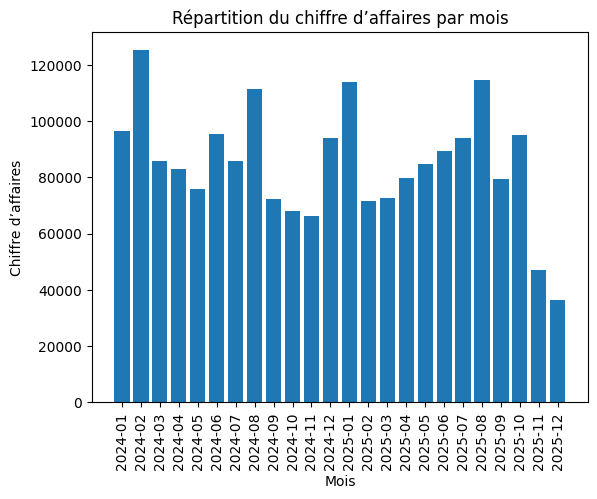

In [ ]:
plt.bar(ca_mensuel["month"].astype(str), ca_mensuel["ca_mensuel"])
plt.title("Répartition du chiffre d’affaires par mois")
plt.xlabel("Mois")
plt.ylabel("Chiffre d’affaires")
plt.xticks(rotation=90)
plt.show()

Le graphique met en évidence les mois les plus performants en chiffre d’affaires et ceux plus faibles, offrant à l’entreprise un aperçu clair pour optimiser ses ventes et sa stratégie.

### Calcul du panier moyen (AOV)

In [ ]:
panier_moyen = df1.groupby("order_id")["net_amount"].sum().mean()
panier_moyen

np.float64(927.2438)

### Calcul Taux de remise moyen (global et par catégorie)

In [ ]:
taux_de_remise_moyen_global = df1["discount_pct"].mean()
taux_de_remise_moyen_global

np.float64(0.11523636363636362)

In [ ]:
taux_de_remise_par_categorie = df1.groupby("category")["discount_pct"].mean().reset_index()
taux_de_remise_par_categorie.rename(columns={"discount_pct": "taux_de_remise_moyen"}, inplace=True)
taux_de_remise_par_categorie

,category,taux_de_remise_moyen
0,Accessoire,0.116500
1,Cloud,0.116379
2,Cours,0.116460
3,Laptop,0.116408
4,Livre,0.113394
5,Logiciel,0.110790


 ### Calcul Taux de retour (global, par catégorie, par canal)

In [ ]:
taux_de_retour_global= df1["returned"].mean()
taux_de_retour_global

np.float64(0.041363636363636366)

In [ ]:
taux_de_retour_par_categorie = df1.groupby("category")["returned"].mean().reset_index()
taux_de_retour_par_categorie.rename(columns={"returned": "taux_de_retour"}, inplace=True)
taux_de_retour_par_categorie

,category,taux_de_retour
0,Accessoire,0.066667
1,Cloud,0.034483
2,Cours,0.040288
3,Laptop,0.043689
4,Livre,0.033333
5,Logiciel,0.034364


### Calcul du Score d’avis moyen (global, par catégorie, par délai de livraison)

In [ ]:
score_avis_moyen_global = df1["review_score"].mean()
score_avis_moyen_global

np.float64(4.337727272727273)

In [ ]:
score_avis_moyen_par_categorie = df1.groupby("category")["review_score"].mean().reset_index()
score_avis_moyen_par_categorie.rename(columns={"review_score": "score_avis_moyen"}, inplace=True)
score_avis_moyen_par_categorie

,category,score_avis_moyen
0,Accessoire,4.408333
1,Cloud,4.271552
2,Cours,4.361151
3,Laptop,4.315534
4,Livre,4.309091
5,Logiciel,4.340206


In [ ]:
score_avis_moyen_par_delai_de_livraison = (
    df1.groupby("delivery_days")["review_score"]
       .mean()
       .reset_index()
       .rename(columns={"review_score": "score_avis_moyen"})
)
score_avis_moyen_par_delai_de_livraison


,delivery_days,score_avis_moyen
0,0.0,4.289634
1,1.0,4.305296
2,2.0,4.349296
3,3.0,4.389558
4,4.0,4.250000
5,5.0,4.435294
6,6.0,4.328125
7,7.0,4.476923
8,8.0,4.309524
9,9.0,4.340909


In [163]:
customers['age'].value_counts()

age
16.0    40
32.0    29
31.0    27
27.0    26
28.0    25
33.0    25
26.0    22
35.0    21
30.0    18
36.0    17
21.0    17
22.0    17
29.0    16
25.0    16
34.0    16
20.0    15
38.0    14
23.0    14
24.0    13
17.0    11
40.0     9
19.0     8
41.0     8
42.0     8
37.0     6
43.0     5
44.0     5
39.0     4
46.0     3
18.0     3
48.0     3
45.0     3
52.0     1
50.0     1
49.0     1
Name: count, dtype: int64